# RF Data Converter Introduction
----

<div class="alert alert-box alert-info">
Please use Jupyter labs http://board_ip_address/lab for this notebook.
</div>

This notebook presents an introduction to the RF Data
Converters (RF DCs) on the ZCU208 board.

## Aims
* Describe the `xrfdc` Python package that is required to control and
  configure the RF DCs from Jupyter
* Investigate the radio hierarchy in the base overlay, allowing the
  user to develop very simple RF designs. 
* Present the data inspection and visualisation of the RF DCs using 
  Plotly.

## Table of Contents
* [Introduction](#introduction)
* [Hardware Setup](#hardware-setup)
* [The Radio Hierarchy](#radio-hierarchy)
* [Transmitter and Receiver](#the-transmitter-and-receiver)
* [RF Data Inspection](#rf-data-inspection)
* [Conclusion](#conclusion)

## References
* [Xilinx, Inc, "USP RF Data Converter: LogiCORE IP Product Guide", PG269, v2.4, November 2020](https://www.xilinx.com/support/documentation/ip_documentation/usp_rf_data_converter/v2_4/pg269-rf-data-converter.pdf)
* [Xilinx, Inc, "Vivado Design Suite: The AXI Reference Guide", UG1037, v4.0, June 2017](https://www.xilinx.com/support/documentation/ip_documentation/axi_ref_guide/latest/ug1037-vivado-axi-reference-guide.pdf)
* [Xilinx, Inc, "ZCU208 Evaluation Board User Guide", UG1410, v1.0, July 2020](https://www.xilinx.com/support/documentation/boards_and_kits/zcu208/ug1410-zcu208-eval-bd.pdf)
* [Xilinx, Inc, "CLK104 RF Clock Add-on Card", UG1437, v1.0, March 2020](https://japan.xilinx.com/support/documentation/boards_and_kits/zcu216/ug1437-clk104.pdf)

## Revision History

* v1.0 | 02/02/2021 | First notebook revision.
* v2.0 | 23/09/2021 | Revised for the ZCU208.
* v3.0 | 27/09/2022 | Additional ADC tiles added to overlay.

----

## Introduction <a class="anchor" id="introduction"></a>

An overview of the Zynq RFSoC device is shown below; there are
three major components:

* Processing System (PS)
* Programmable Logic (PL)
* RF Data Converters (RF DC, including ADC and DAC)

The RF data converters are significant features of the Zynq RFSoC
device as they interface directly to the PL.
This brings many advantages, including the ability to
perform direct RF sampling and low-latency processing.

The ZCU208 is a Gen 3 RFSoC platform consisting of an XCZU48DR-FSVG1517-2-E RFSoC device, 
which contains the following RF DCs:

* 8x RF Analogue-to-Digital Converters (RF ADCs)
    * Sample rate of 5 GSPS
    * 14-bit conversion
* 8x RF Digital-to-Analogue Converters (RF DACs)
    * Sample rate of 7 GSPS
    * 14-bit conversion

Let's take a closer look at the RF DC block. Starting with
the RF ADC tiles, you will notice that there are 4 tiles on this
particular RFSoC device. Each tile contains 2 RF ADC blocks, 
which can be used to receive, or Digital Down Convert (DDC), 
an analogue signal. Each RF ADC block contains:

* A gearbox FIFO
* 1x (bypass), 2x, 3x, 4x, 5x, 6x, 8x, 10x, 12x, 16x, 20x, 24x or 40x decimator
* A complex mixer
* A Quadrature Modulation Correction (QMC) unit
* Embedded Digital Step Attenuator (DSA)
* On-chip clock distribution network

The image below presents the typical RF ADC processing 
pipeline:

1. The RF ADC samples the input waveform to convert it
   into a digital signal.
2. A threshold detector can be employed to detect and record
   input amplitude levels. 
3. The QMC is used to offset potential imbalance in the
   quality of the received complex signal.
4. The I and Q mixer can mix the input signal to baseband.
5. The I and Q decimators are capable of a wide range of
   decimation options before interfacing the PL via the gearbox FIFO.

<img src='data/rfsystem_rfadc_block_overview.png' align='left' style='left' height='75%' width='75%'/>

The RF DAC block has a similar pipeline to the RF ADC;
however, it is in reverse this time for Digital Up Conversion (DUC).

1. The data to be transmitted is interfaced to the RF DAC block from the PL.
2. The digital signal is interpolated by a factor of 1x (bypass), 2x, 3x, 4x, 5x, 6x, 8x, 10x, 12x, 16x, 20x, 24x    or 40x.
3. The digital signal is transferred to the complex mixer to be mixed
   to the desired carrier frequency. 
4. After the QMC and coarse delay block, the signal can optionally
   be convolved with an inverse (anti) sinc filter to improve the
   roll-off of the first Nyquist zone.
5. The digital signal is then converted to analogue through the
   RF DAC sampler.


<img src='data/rfsystem_rfdac_block_overview.png' align='left' style='left' height='75%' width='75%'/>

# Hardware Setup <a class="anchor" id="hardware-setup"></a>

The CLK104 add on board should be connected to the RFDCs using SMCs. This will enable a connection from the LMX to the on tile PLLs associated with ADC tile 225 and DAC tile 230. Clock distribution will be used to provide this clock to the other active tiles.

Your ZCU208 board is capable of 8 channels, dependent on hardware configuration. Loopback is possible through the use of the XM655 add on card included with the ZCU208 kit. There are 8 JHC connections from the RFDC to the break out board. For this demonstration we will be using 2 DAC channels (JHC3) as the source.  Four ADC channels are configured but only 2 ADC channels (JHC5, JHC7) are captured at a time. You should create the loopback connection using SMA cables as shown below.  The DC Block and male-to-male adapters are necessary to complete the connections and are shown further below.

## Configuration One
* DAC Tile 230 (channel 2) to ADC Tile 224 (channel 0)
* DAC Tile 231 (channel 3) to ADC Tile 225 (channel 1)

## Configuration Two
* DAC Tile 230 (channel 2) to ADC Tile 226 (channel 2)
* DAC Tile 231 (channel 3) to ADC Tile 227 (channel 3)

## The Radio Hierarchy <a class="anchor" id="radio-hierarchy"></a>

We need to add custom control logic in the PL to communicate
with the RF ADC or RF DAC. The ZCU208 base overlay contains
such logic that will allow you to evaluate the RF DCs. 
There are two IP Cores - the transmitter and the receiver.

* **Amplitude Controller** - can apply a value to the input of the RF DAC.
The value can be set by writing to an AXI-Lite register. 
The register value can be mixed with the Numerically
Controlled Oscillator (NCO) in the fine mixer to create a tone. 
The tone is looped back round into the RF ADC.

* **Packet Generator** - interfaces to the output of RF ADC block. 
The data is used to generate an [AXI-Stream packet](https://www.xilinx.com/support/documentation/ip_documentation/axi_ref_guide/latest/ug1037-vivado-axi-reference-guide.pdf).
The AXI-Stream packet is sent to an AXI Direct Memory
Access (DMA) core and transferred to DDR memory.

These 2 IP cores are connected to each channel of the ZCU208 board.
They are conveniently placed inside a hierarchical block, `radio`, 
as shown below.

In [1]:
# import plotly.graph_objs as go
import matplotlib.pyplot as plt
# import ipywidgets as ipw

import pandas as pd
import numpy as np
from scipy import signal
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = [8.0, 5]
mpl.rcParams['axes.grid'] = True
mpl.rcParams['axes.grid.which'] = "both"
mpl.rcParams['grid.linewidth'] = 0.5
mpl.rcParams['grid.alpha'] = 0.5


In [2]:
from pynq import Clocks
from pynq.overlays.base import BaseOverlay
import xrfdc

base = BaseOverlay('base.bit')

In [3]:
base.is_loaded()

True

In [4]:
base?

Type:            BaseOverlay
String form:     <pynq.overlays.base.base.BaseOverlay object at 0xffff865b2dd0>
File:            /usr/local/share/pynq-venv/lib/python3.10/site-packages/pynq/overlays/base/base.py
Docstring:      
Default documentation for overlay base.bit. The following
attributes are available on this overlay:

IP Blocks
----------
OffloadEngine/axi_dma_0 : pynq.lib.dma.DMA
OffloadEngine/xxv_ethernet_0 : pynq.overlay.DefaultIP
btns_gpio            : pynq.lib.axigpio.AxiGPIO
leds_gpio            : pynq.lib.axigpio.AxiGPIO
sws_gpio             : pynq.lib.axigpio.AxiGPIO
system_management_wiz_0 : pynq.overlay.DefaultIP
axi_intc_0           : pynq.overlay.DefaultIP
radio/receiver/channel_00/axi_dma_imag : pynq.lib.dma.DMA
radio/receiver/channel_00/axi_dma_real : pynq.lib.dma.DMA
radio/receiver/channel_00/packet_generator : rfsystem.receiver.PacketGenerator
radio/receiver/channel_10/axi_dma_imag : pynq.lib.dma.DMA
radio/receiver/channel_10/axi_dma_real : pynq.lib.dma.DMA
radio

## LEDS and switches
* LEDS: PL LEDS
* Switches: SW14

In [31]:
leds = base.leds_gpio.channel1
switches = base.sws_gpio.channel1

leds.write(0x5, mask=0xff)
switches.setdirection("in")
switches.setlength(8)
switches.read()

5

In [34]:
base.radio.rfdc.ClkDistribution['DAC'][0]

{'SourceTile': 1,
 'PLLEnable': 1,
 'PLLSettings': {'Enabled': 1,
  'RefClkFreq': 491.52,
  'SampleRate': 4.9152,
  'RefClkDivider': 1,
  'FeedbackDivider': 20,
  'OutputDivider': 2,
  'FractionalMode': 0,
  'FractionalData': 0,
  'FractWidth': 0},
 'DivisionFactor': 2,
 'Delay': 252,
 'DistributedClock': 0}

In [35]:
base.radio.rfdc.ClkDistribution['ADC'][0]

{'SourceTile': 6,
 'PLLEnable': 1,
 'PLLSettings': {'Enabled': 1,
  'RefClkFreq': 491.52,
  'SampleRate': 4.9152,
  'RefClkDivider': 1,
  'FeedbackDivider': 20,
  'OutputDivider': 2,
  'FractionalMode': 0,
  'FractionalData': 0,
  'FractWidth': 0},
 'DivisionFactor': 2,
 'Delay': 12,
 'DistributedClock': 0}

The ZCU208 has a sophisticateblockscking network, which can generate
low-jitter clocks for the RF DC Phase-Locked Loops (PLLs).

The base overlay
has a simple method `base.init_rfclks()` to initialize these clocks, which set
the LMK and LMX clocks to 245.76MHz and 491.52MHz, respectively.

In [36]:
print(f'CPU:   {Clocks.cpu_mhz:10.3f} MHz')
print(f'FCLK0: {Clocks.fclk0_mhz:10.3f} MHz')
print(f'FCLK1: {Clocks.fclk1_mhz:10.3f} MHz')
print(f'FCLK2: {Clocks.fclk2_mhz:10.3f} MHz')
print(f'FCLK3: {Clocks.fclk3_mhz:10.3f} MHz')

CPU:     1199.988 MHz
FCLK0:     99.999 MHz
FCLK1:    299.997 MHz
FCLK2:    499.995 MHz
FCLK3:     99.999 MHz


We can see the `transmitter` and `receiver` hierarchies. 
The RF DC object is also available, however, we don't need this. The reason
is that each transmitter and receiver is automatically paired with their
associated RF DC tile and block.

The `radio` hierarchy also initializes all of the active RF ADC and RF DAC
blocks to sample at 4915.2 MSPS (close to the maximum sample rate for the RF ADC).

The decimation factor is 2, so the ADC waveform sampling rate is 4915.2 / 2 = 2457.6 MHz.

By default the RF DAC and RF ADC mixer frequencies are 1228.8 MHz, which is
in the center of the first Nyquist Zone.

## Transmitter and Receiver <a class="anchor" id="the-transmitter-and-receiver"></a>

The transmitter hierarchy contains two channels. Each channel contains an
*Amplitude Controller* connected directly to an RF DAC. We can list the
available channels of the transmitter using the `get_channel_description()`
method.

The report above states that there are two active channels in the system.

The receiver hierarchy also contains two channels. The *Packet Generator*
arranges the data into AXI-Stream packets and sends these packets to DDR
memory via AXI DMA. Let's run the cell below.

In [37]:
base.radio.receiver.get_channel_description()

{'Channel 0': {'Tile': 224, 'Block': 0},
 'Channel 1': {'Tile': 225, 'Block': 0},
 'Channel 2': {'Tile': 226, 'Block': 0},
 'Channel 3': {'Tile': 227, 'Block': 0}}

In [38]:
base.radio.transmitter.get_channel_description()

{'Channel 0': {'Tile': 228, 'Block': 0},
 'Channel 1': {'Tile': 229, 'Block': 0},
 'Channel 2': {'Tile': 230, 'Block': 0},
 'Channel 3': {'Tile': 231, 'Block': 0}}

There are several methods to read and write to RF block registers.
These methods are common to the RF DAC and RF ADC.

```python
BlockStatus
MixerSettings
QMCSettings
CoarseDelaySettings
NyquistZone
```

For example, `base.radio.transmitter.channel[0].dac_block.QMCSettings`
will display the QMC settings for the transmit DAC block.

For many of these settings, you can change them and they will impact the operation.

In [46]:
adc0_block = base.radio.rfdc.adc_tiles[0].blocks[0]
display(adc0_block.BlockStatus)
display(adc0_block.MixerSettings)
display(adc0_block.QMCSettings)
display(adc0_block.CoarseDelaySettings)
display(adc0_block.NyquistZone)

{'SamplingFreq': 4.9152,
 'AnalogDataPathStatus': 1,
 'DigitalDataPathStatus': 801,
 'DataPathClocksStatus': 1,
 'IsFIFOFlagsEnabled': 3,
 'IsFIFOFlagsAsserted': 0}

{'Freq': -1228.8,
 'PhaseOffset': 0.0,
 'EventSource': 2,
 'CoarseMixFreq': 0,
 'MixerMode': 3,
 'FineMixerScale': 1,
 'MixerType': 2}

{'EnablePhase': 0,
 'EnableGain': 0,
 'GainCorrectionFactor': 0.0,
 'PhaseCorrectionFactor': 0.0,
 'OffsetCorrectionFactor': 0,
 'EventSource': 0}

{'CoarseDelay': 0, 'EventSource': 0}

1

In [47]:
def get_adc_wfm(n_samples=256):
    return np.array([
        chan.transfer(n_samples) 
        for chan in base.radio.receiver.channel])

def plot_adc_wfm(cdata, fs=2.4576, width=12, height=4):
    n_ch, n_samples = cdata.shape
    t = np.arange(0, n_samples/fs, 1/fs)
    fig, axes = plt.subplots(
        n_ch, sharex=True, figsize=(width, n_ch*height))
    for i, (wfm, ax) in enumerate(zip(cdata, axes)):
        ax.plot(t, wfm.real, label='Real')
        ax.plot(t, wfm.imag, label='Imag')
        ax.set_title(f'ADC {i} ')
        ax.legend()
        ax.set_xlabel('Time [ns]')

In [48]:
def plot_adc_psd(wfm, fs=2457.6, width=12, height=4):
    f, pxxs = signal.periodogram(
        wfm, fs, 'flattop', scaling='spectrum', return_onesided=False)
    f = np.fft.fftshift(f)
    pxxs = np.fft.fftshift(pxxs, axes=1)
    n_ch, n_samples=wfm.shape
    fig, axes = plt.subplots(
        n_ch, sharex=True, figsize=(width, n_ch*height))
    for i, (pxx, ax) in enumerate(zip(pxxs, axes)):
        ax.plot(f, 10*np.log10(pxx))
        f_peak = f[np.argmax(pxx)]
        ax.set_title(f'ADC {i}, peak: {f_peak:.3f} MHz ')
        ax.set_xlabel('Freq [MHz]')
        ax.set_ylabel('Power [dBFS]')

## RF Data Inspection <a class="anchor" id="rf-data-inspection"></a>


In [49]:
base.radio.transmitter.channel[2].dac_block.MixerSettings['Freq'] = 1228.8 - 9.6  # MHz
base.radio.transmitter.channel[3].dac_block.MixerSettings['Freq'] = 1228.8 + 9.6  # MHz
# base.radio.transmitter.channel[2].dac_block.MixerSettings['Freq'] = 600 + 0.6 # MHz
# base.radio.transmitter.channel[3].dac_block.MixerSettings['Freq'] = 600 # MHz

In [50]:
for chan in base.radio.receiver.channel:
    chan.adc_block.MixerSettings['Freq'] = 1228.8

In [51]:
for chan in base.radio.transmitter.channel:
    chan.control.gain = 0.8
    chan.control.enable = True

## RF-ADC Mixer settings
* Bypass mixer

In [50]:
for chan in base.radio.receiver.channel:
    chan.adc_block.MixerSettings = {
        'Freq': 0,
        'PhaseOffset': 0.0,
        'EventSource': xrfdc.EVNT_SRC_TILE,
        'CoarseMixFreq': xrfdc.COARSE_MIX_BYPASS,
        'MixerMode': xrfdc.MIXER_MODE_R2C,
        'FineMixerScale': xrfdc.MIXER_SCALE_AUTO,
        'MixerType': xrfdc.MIXER_TYPE_COARSE}

* Coarse mixer at $Fs/4$

In [52]:
for chan in base.radio.receiver.channel:
    chan.adc_block.MixerSettings = {
        'Freq': 0,
        'PhaseOffset': 0.0,
        'EventSource': xrfdc.EVNT_SRC_TILE,
        'CoarseMixFreq': xrfdc.COARSE_MIX_SAMPLE_FREQ_BY_FOUR,
        'MixerMode': xrfdc.MIXER_MODE_R2C,
        'FineMixerScale': xrfdc.MIXER_SCALE_AUTO,
        'MixerType': xrfdc.MIXER_TYPE_COARSE}

* Fine mixer

In [62]:
for chan in base.radio.receiver.channel:
    chan.adc_block.MixerSettings = {
        'Freq': 1228.8,
        'PhaseOffset': 30.0,
        'EventSource': xrfdc.EVNT_SRC_TILE,
        'CoarseMixFreq': xrfdc.COARSE_MIX_OFF,
        'MixerMode': xrfdc.MIXER_MODE_R2C,
        'FineMixerScale': xrfdc.MIXER_SCALE_AUTO,
        'MixerType': xrfdc.MIXER_TYPE_FINE}

In [63]:
base.radio.rfdc.adc_tiles[0].blocks[0].MixerSettings

{'Freq': 1228.8,
 'PhaseOffset': 29.999542236328125,
 'EventSource': 2,
 'CoarseMixFreq': 0,
 'MixerMode': 3,
 'FineMixerScale': 0,
 'MixerType': 2}

In [64]:
base.radio.rfdc.adc_tiles[0].blocks[0].BlockStatus

{'SamplingFreq': 4.9152,
 'AnalogDataPathStatus': 1,
 'DigitalDataPathStatus': 801,
 'DataPathClocksStatus': 1,
 'IsFIFOFlagsEnabled': 3,
 'IsFIFOFlagsAsserted': 0}

In [65]:
cdata = get_adc_wfm(256*32)

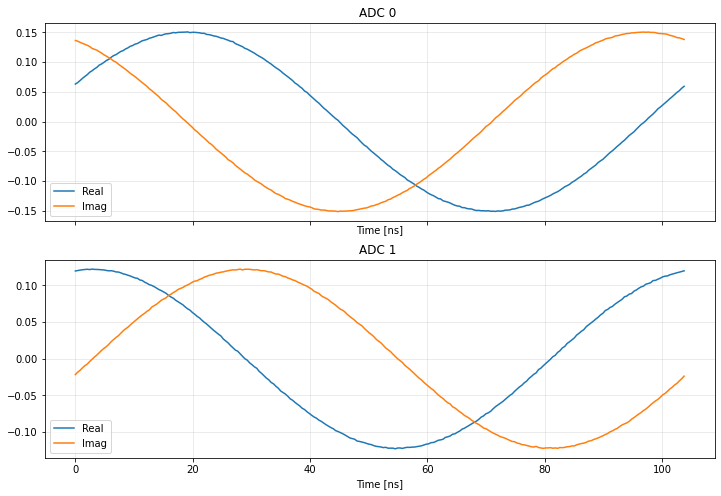

In [66]:
plot_adc_wfm(cdata[:2, :256])

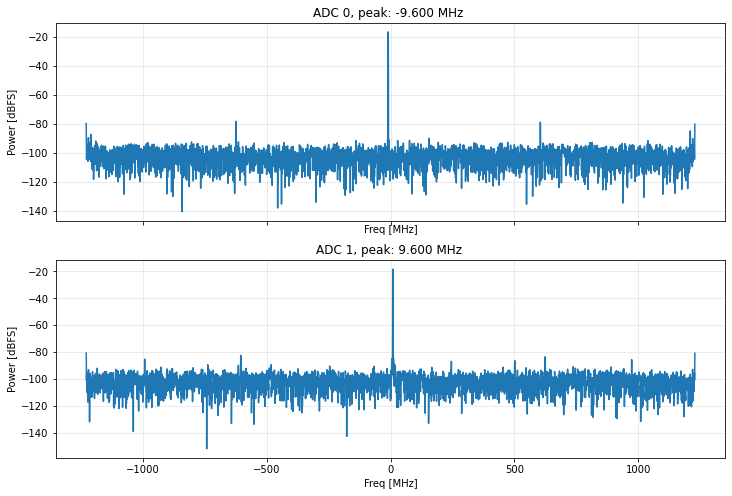

In [67]:
plot_adc_psd(cdata[:2])